## Homework Training a Neural Network

# HOMEWORK

- Reimplement the NeuralNetwork class by using the Perceptron class inside it (e.g. a layer is an array of perceptrons)
- Inside the class extract weights and other info from the Perceptrons to allow vector-matrix efficient multiplications
- (BONUS) make everything not using matrix multiplications, but rather for loops iterating over list of Perceptrons

### 6.1 Importing Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# For reproducibility
np.random.seed(42)

### 6.2 Generating a Dataset

We'll use the 'make_moons' dataset, which creates two interleaving half circles.

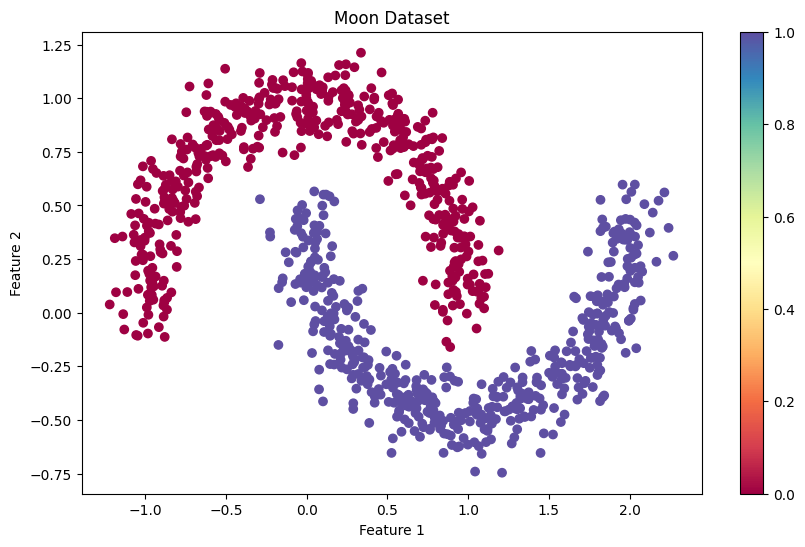

In [2]:
# Generate the dataset
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral)
plt.title('Moon Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar()
plt.show()

In [3]:
class Perceptron:
    def __init__(self, input_size, activation_function):
        self.weights = np.random.randn(input_size)
        self.bias = np.random.randn()
        self.activation_function = activation_function
    
    def activate(self, x):
        z = np.dot(x, self.weights) + self.bias
        return self.activation_function(z)

In [12]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # Create layers of Perceptrons instead of using weight matrix
        self.hidden_layer = [Perceptron(input_size, self.leaky_relu) for _ in range(hidden_size)]
        self.output_layer = [Perceptron(hidden_size, self.sigmoid) for _ in range(output_size)]
        
        # Extract weight matrices for efficient computation
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1.0 / input_size)
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1.0 / hidden_size)
        self.b1 = np.zeros((1, hidden_size))  
        self.b2 = np.zeros((1, output_size))  

    def relu(self, x):
        """ReLU activation function"""
        return np.maximum(0, x)
   
    def relu_derivative(self, x):
        """Derivative of ReLU"""
        return np.where(x > 0, 1, 0)
    
    def leaky_relu(self, x, alpha=0.01):
        return np.where(x > 0, x, alpha * x)

    def sigmoid(self, x):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))  # Clip to prevent overflow
    
    def sigmoid_derivative(self, x):
        """Derivative of sigmoid"""
        s = self.sigmoid(x)
        return s * (1 - s)
    
    def forward(self, X):
        """Efficient forward pass using matrix operations"""
        self.z1 = np.dot(X, self.W1) + self.b1  # Shape: (num_samples, hidden_size)
        self.a1 = self.relu(self.z1)            # Shape: (num_samples, hidden_size)
        
        self.z2 = np.dot(self.a1, self.W2) + self.b2  # Shape: (num_samples, output_size)
        self.a2 = self.sigmoid(self.z2)               # Shape: (num_samples, output_size)
        
        return self.a2
     
    def compute_loss(self, y_true, y_pred):
        """Binary cross-entropy loss"""
        m = y_true.shape[0]
        loss = -np.sum(y_true * np.log(y_pred + 1e-15) + (1 - y_true) * np.log(1 - y_pred + 1e-15)) / m
        return loss
    
    def backward(self, X, y):
        """Compute gradients for backpropagation"""
        m = X.shape[0]
        
        # Compute output layer gradient
        dz2 = self.a2 - y.reshape(-1, 1)
        dW2 = np.dot(self.a1.T, dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m
        
        # Compute hidden layer gradient
        dz1 = np.dot(dz2, self.W2.T) * self.relu_derivative(self.z1)
        dW1 = np.dot(X.T, dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m
        
        return dW1, db1, dW2, db2
    
    def update_parameters(self, dW1, db1, dW2, db2, learning_rate):
        """Update weights and biases using gradient descent"""
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2

    def train(self, X, y, learning_rate=0.1, epochs=1000, print_every=100):
        losses = []
        
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y.reshape(-1, 1), y_pred)
            losses.append(loss)
            
            # Backward pass
            dW1, db1, dW2, db2 = self.backward(X, y)
            
            # Update weights
            self.update_parameters(dW1, db1, dW2, db2, learning_rate)
            
            if epoch % print_every == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
        
        return losses

    
    def predict(self, X, threshold=0.5):
        """Make binary predictions"""
        y_pred = self.forward(X)
        return (y_pred >= threshold).astype(int)

### 6.4 Training the Network

In [30]:
# set hyperparameters
hidden_size = 15
learning_rate = 0.15
epochs = 2000

# Create a neural network 
nn = NeuralNetwork(input_size=2, hidden_size=hidden_size, output_size=1)

# Train the network
losses = nn.train(X_train, y_train, learning_rate=learning_rate, epochs=epochs, print_every=round(epochs/10))

Epoch 0, Loss: 0.7042
Epoch 200, Loss: 0.2294
Epoch 400, Loss: 0.2176
Epoch 600, Loss: 0.2101
Epoch 800, Loss: 0.1949
Epoch 1000, Loss: 0.1663
Epoch 1200, Loss: 0.1276
Epoch 1400, Loss: 0.0941
Epoch 1600, Loss: 0.0709
Epoch 1800, Loss: 0.0556


### 6.5 Visualizing the Training Progress

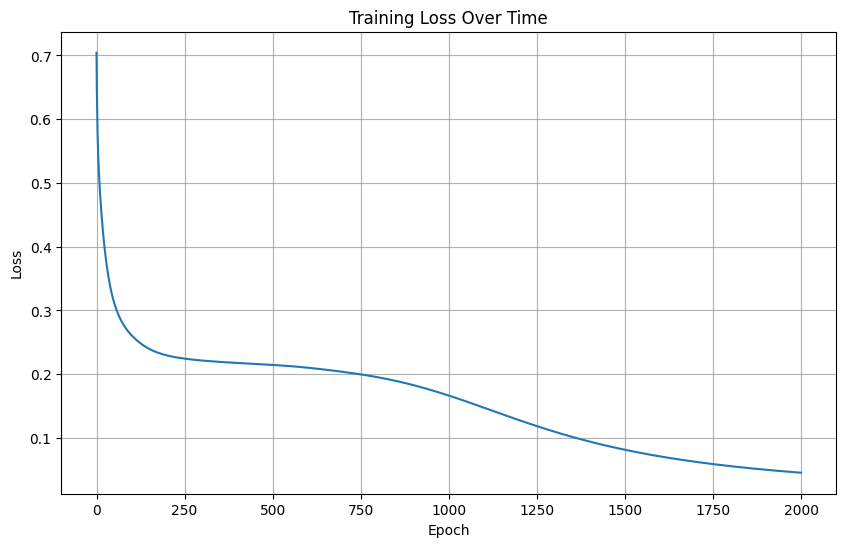

In [31]:
# Plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

### 6.6 Evaluating the Model

In [32]:
# Make predictions on test set
y_pred = nn.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.9950


### 6.7 Visualizing the Decision Boundary

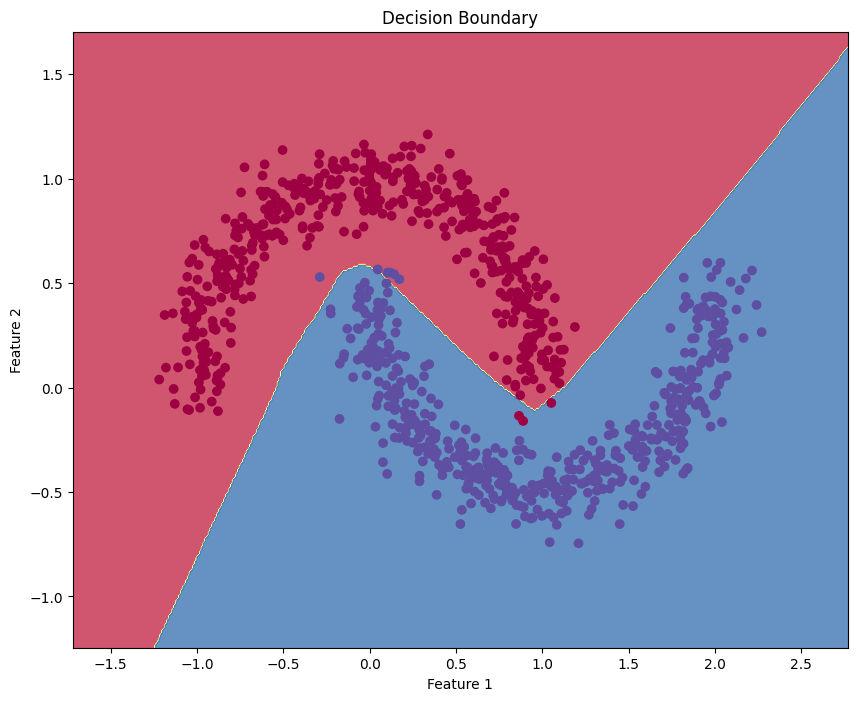

In [33]:
def plot_decision_boundary(X, y, model):
    """Plot the decision boundary of the trained model"""
    # Set min and max values with some margin
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # Generate a grid of points
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # Make predictions on the grid points
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the contour and training examples
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Decision Boundary')
    plt.show()

# Plot the decision boundary
plot_decision_boundary(X, y, nn)

## Prova BONUS 
non va.. da rivedere le dimensioni 

In [61]:
class Perceptron:
    def __init__(self, input_size, activation_function, activation_derivative):
        self.weights = np.random.randn(input_size) * np.sqrt(1.0 / input_size)
        self.bias = np.random.randn()
        self.activation_function = activation_function
        self.activation_derivative = activation_derivative
        
    def activate(self, x):
        self.z = sum(w * x_i for w, x_i in zip(self.weights, x)) + self.bias
        self.a = self.activation_function(self.z)
        return self.a

In [66]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        # Create layers of Perceptrons
        self.hidden_layer = [Perceptron(input_size, self.leaky_relu, self.leaky_relu_derivative) for _ in range(hidden_size)]
        self.output_layer = [Perceptron(hidden_size, self.sigmoid, self.sigmoid_derivative) for _ in range(output_size)]
        
    def relu(self, x):
        return max(0, x)
    
    def leaky_relu(self, x, alpha=0.01):
        return x if x > 0 else alpha * x

    def leaky_relu_derivative(self, x, alpha=0.01):
        return 1 if x > 0 else alpha

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        s = self.sigmoid(x)
        return s * (1 - s)
        
    def forward(self, X):
        """Forward pass -->  using explicit loops"""
        hidden_outputs = [[p.activate(x)] for x in X for p in self.hidden_layer]
        hidden_outputs = np.array(hidden_outputs).reshape(len(X), len(self.hidden_layer))

        final_outputs = [[p.activate(h)] for h in hidden_outputs for p in self.output_layer]
        return np.array(final_outputs).reshape(len(X), len(self.output_layer))

    def backward(self, X, y, y_pred, learning_rate):
        """Retropropagazione senza matrici"""
        m = len(y)

        # Calcolo del gradiente per lo strato di output
        output_deltas = [(y_predict - y_i) * p.activation_derivative(p.z) for y_i, y_predict, p in zip(y, y_pred.flatten(), self.output_layer)]
        
        # Calcolo del gradiente per lo strato nascosto
        hidden_deltas = [0] * len(self.hidden_layer)
        for i, hidden_perceptron in enumerate(self.hidden_layer):
            error = sum(delta * output_p.weights[i] for delta, output_p in zip(output_deltas, self.output_layer))
            hidden_deltas[i] = error * hidden_perceptron.activation_derivative(hidden_perceptron.z)

        # Aggiorna i pesi per lo strato di output
        for i, output_p in enumerate(self.output_layer):
            for j in range(len(self.hidden_layer)):
                output_p.weights[j] -= learning_rate * output_deltas[i] * output_p.a
            output_p.bias -= learning_rate * output_deltas[i]

        # Aggiorna i pesi per lo strato nascosto
        for i, hidden_p in enumerate(self.hidden_layer):
            for j in range(len(X[0])):  # numero di input
                hidden_p.weights[j] -= learning_rate * sum(hidden_deltas[i] * X[i][j] for i in range(m)) / m
           
            hidden_p.bias -= learning_rate * sum(hidden_deltas[i] for i in range(m)) / m


    def compute_loss(self, y_true, y_pred):
        """Binary cross-entropy loss"""
        m = len(y_true)
        loss = -sum(y * np.log(y_predict + 1e-15) + (1 - y) * np.log(1 - y_predict + 1e-15) #1e-15 per evitare log(0)
                    for y, y_predict in zip(y_true, y_pred.flatten())) / m
        return loss

    
    def train(self, X, y, learning_rate=0.1, epochs=1000, print_every=100):
        """Training loop  -->  without matrix multiplications"""
        losses = []
        
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y, y_pred)
            losses.append(loss)

            self.backward(X, y, y_pred, learning_rate)
            
            if epoch % print_every == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
        
        return losses
    
    def predict(self, X, threshold=0.5):
        y_pred = self.forward(X)
        return (y_pred >= threshold).astype(int)

In [67]:
# Set hyperparameters
hidden_size = 10
learning_rate = 0.1
epochs = 2000

# Create and train the neural network
nn = NeuralNetwork(input_size=2, hidden_size=hidden_size, output_size=1)
losses = nn.train(X_train, y_train, learning_rate=learning_rate, epochs=epochs, print_every=round(epochs / 10))

IndexError: list index out of range